#ISE291 Project, Group1, Section F06
#Students: Norah Al Diri, Wed Alghamdi, Fatimah Alhulaily, Mayar Bawazeer، Fatimah Alqudihi
#ID's: 202353070, 202356410, 202347850, 202364170, 202344070
#Project Field: Sleep Health and Lifestyle

# 1. Discovery

## 1.1 Background

Sleep plays an essential role in maintaining physical and mental well-being.  
In recent years, many people have experienced poor sleep quality or irregular sleep patterns due to stress, work pressure, lifestyle habits, and various health conditions. These factors contribute to sleep disorders such as insomnia and sleep apnea.

With the availability of health-related datasets, data science techniques allow us to analyze sleep behavior and identify patterns that may help predict individuals who are at higher risk of developing sleep disorders. Such insights can support healthcare practitioners, wellness programs, and policy makers in improving overall sleep health.

---

## 1.2 Problem Statement

The main problem addressed in this project is:

> **Predicting whether an individual has a sleep disorder (None, Insomnia, or Sleep Apnea) based on demographic, lifestyle, and health-related features.**

The goal is to build a model that identifies meaningful patterns and classifies each individual into the correct sleep disorder category.

---

## 1.3 Objectives

The objectives of this analysis are:

1. To understand how demographic and lifestyle factors influence sleep health.  
2. To clean and preprocess the dataset to make it suitable for machine learning modeling.  
3. To build and compare classification models that can predict sleep disorder types.  
4. To deliver insights and recommendations based on the findings of the analysis.

---

## 1.4 Data Description

This project uses the **Sleep Health and Lifestyle** dataset, which contains demographic, lifestyle, and health variables related to sleep patterns.

- **Dataset size:** 374 observations  
- **Number of variables:** 13  
- **Type of features:** Mixed (numerical + categorical)  
- **Target variable:** `Sleep Disorder`

The dataset includes features such as:
- Age  (Age)
- Gender (Gender)
- Occupation  (Occupation)
- Sleep Duration  (SlpDur)
- Sleep Quality  (SlpQ)
- Physical Activity Level  (PhysActL)
- Stress Level  (StressL)
- BMI Category  (BMIcategory)
- Blood Pressure  (Blood_Pressure)
- Heart Rate  (Heart_Rate)
- Daily Steps  (Daily_Steps)

This dataset is appropriate for our project because:
- It contains more than the required 300 observations.  
- It includes mixed-type input variables.  
- It provides a clear categorical target suitable for classification models.

---

## 1.5 Selected Modeling Technique: Classification

Since the target variable (`Sleep Disorder`) is **categorical**, the most suitable modeling technique is **classification**.

The categories are:
- None  
- Insomnia  
- Sleep Apnea  

In later stages, we will experiment with several classification algorithms and select the best-performing model.

---

## 1.6 Stakeholders

The results of this project can benefit:
- **Healthcare providers:** identifying individuals at risk of sleep disorders early.  
- **Wellness & fitness programs:** improving lifestyle recommendations.  
- **Researchers:** studying correlations between lifestyle habits and sleep.  
- **Organizations:** supporting employee wellness and productivity strategies.

---

# End of Discovery


# 2. Data Preparation

## 2.1 Types of Variables

| Column Name | Type |
| :------- | :------: |
| Id | Numerical
| Gender | Categorical
| Age | Numerical
| Occupation | Categorical
| SlpDur | Numerical
| PhysActL | Numerical
| StressL | Numerical
| BMIcategory | Categorical
| Blood_Pressure | Numerical
| Heart_rate | Numerical
| Daily_Steps | Numerical
| Sleep_Disorder | Categorical

## 2.2 Mapping Duplicates, Missing values, Noise and Inconsistencies

## 2.2.1 Noise (Incorrect Data)
In this data set, there are several cases where data is recorded incorrectly, and they are :

- **Id** Some rows has Id as negative number which is incorrect.
- **Age** Some ages are impossible such as : 0, above 100.
- **PhysActL** some records in this column are negative.  
- **Heart_Rate** Some records in this column are less than zero.
- **Daily_Steps** Some records in this column are less than zero.

## 2.2.2 Missing data
In this data set, there are several columns that have missing (Nan) values:

- **Id**
- **Gender**
- **Age**
- **Occupation**
- **SlpDur**
- **PhysActL**
- **StressL**
- **BMIcategory**
- **Blood_Pressure**
- **Heart_Rate**
- **Daily_Steps**
- **Heart_Rate**
- **Sleep_Disorder**

## 2.2.3 Inconsistencies
In this data set, there are several rows where data is recorded in inappropriate format, these columns are:

- **Age** : Some ages are written as string (text) not as a numerical value.
- **SlpQ** : Some rows are mentioned as text not as numerical values.
- **StressL** : Some rows are mentioned as text such as : extreme, low,...etc rather than numbers.
- **Blood_Pressure** : Some rows are mentioned as text not as numerical values.
- **Daily_Steps** : Some rows are mentioned as text not as numerical values.

## 2.2.4 Duplicates
In this data set, there are several rows where data is duplicated, and these rows are:

- **row 2 and row 3** : Some ages are written as string (text) not as a numerical value.
- **SlpQ** : Some rows are mentioned as text not as numerical values.
- **StressL** : Some rows are mentioned as text such as : extreme, low,...etc rather than numbers.
- **Blood_Pressure** : Some rows are mentioned as text not as numerical values.
- **Daily_Steps** : Some rows are mentioned as text not as numerical values.

## 3. Data Cleaning


In [143]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_excel("Sleep_health_and_lifestyle_dataset_dirty.xlsx")

clean_df = df.copy()

# Display summary before cleaning
print("Missing values before cleaning:")
print(clean_df.isna().sum())
print("\nData summary before cleaning:")
print(clean_df.info())

# Drop rows with any NaN
clean_df = clean_df.dropna()

# Fill numeric missing values with mean
numeric_cols = clean_df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    clean_df[col] = clean_df[col].fillna(clean_df[col].mean())

# Fill categorical missing values with mode
categorical_cols = clean_df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    clean_df[col] = clean_df[col].fillna(clean_df[col].mode()[0])

# Display summary after cleaning
print("\nMissing values after cleaning:")
print(clean_df.isna().sum())
print("\nData summary after cleaning:")
print(clean_df.info())

# Save cleaned dataset as Excel file
clean_df.to_excel("cleaned_dataset_member3.xlsx", index=False)
print("\nCleaned file saved as: cleaned_dataset_member3.xlsx")


Missing values before cleaning:
id                  5
Gender             14
Age                 5
Occupation         30
SlpDur              5
SlpQ               26
PhysActL           36
StressL            25
BMIcategory         6
Blood_Pressure     22
Heart_Rate         15
Daily_Steps        29
Sleep_Disorder    222
dtype: int64

Data summary before cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              369 non-null    float64
 1   Gender          360 non-null    object 
 2   Age             369 non-null    object 
 3   Occupation      344 non-null    object 
 4   SlpDur          369 non-null    float64
 5   SlpQ            348 non-null    object 
 6   PhysActL        338 non-null    float64
 7   StressL         349 non-null    object 
 8   BMIcategory     368 non-null    object 
 9   Blood_Pressure  352 non-null    o

**Explanation**:

-Loaded the dataset into a pandas DataFrame.

-Displayed a full summary of the data, including missing values and data types.

-Dropped all rows that contained any missing values (NaN).

-Identified numeric and categorical columns.

-Filled missing values in numeric columns using the mean of each column.

-Filled missing values in categorical columns using the mode (most frequent value).

-Displayed a summary after cleaning to confirm that all missing values were handled.

-Saved the cleaned dataset as an Excel file named cleaned_dataset.xlsx.

## 4. Solving inconsistency


In [146]:
import pandas as pd
import numpy as np

df = pd.read_excel("cleaned_dataset_member3.xlsx")

clean_df = df.copy()

clean_df['Gender'] = (
    clean_df['Gender']
      .astype(str)
      .str.strip()
      .str.lower()
      .replace({'male': 'Male', 'female': 'Female'})
)

# BMIcategory
clean_df['BMIcategory'] = (
    clean_df['BMIcategory']
      .astype(str)
      .str.strip()
      .str.title()
      .replace({
          'Obse': 'Obese',
          'Owerweight': 'Overweight',
          'Norml': 'Normal'
      })
)

# Occupation
clean_df['Occupation'] = (
    clean_df['Occupation']
      .astype(str)
      .str.strip()
      .replace({
          'Techer': 'Teacher',
          'Lowyer': 'Lawyer',
          'Softeeware Engineer': 'Software Engineer',
          'Scintist': 'Scientist',
          'Accountaent': 'Accountant'
      })
)

# Sleep_Disorder
clean_df['Sleep_Disorder'] = clean_df['Sleep_Disorder'].replace({
    'NoneType': 'None',
    'maybe': np.nan,
    'yes': np.nan,
    'abc': np.nan
})


# Age: convert to numeric and fix impossible values
clean_df['Age'] = pd.to_numeric(clean_df['Age'], errors='coerce')
clean_df.loc[(clean_df['Age'] < 0) | (clean_df['Age'] > 120), 'Age'] = np.nan

# Heart Rate
clean_df['Heart_Rate'] = pd.to_numeric(clean_df['Heart_Rate'], errors='coerce')
clean_df.loc[(clean_df['Heart_Rate'] < 30) | (clean_df['Heart_Rate'] > 220), 'Heart_Rate'] = np.nan

# Daily Steps
clean_df['Daily_Steps'] = pd.to_numeric(clean_df['Daily_Steps'], errors='coerce')
clean_df.loc[clean_df['Daily_Steps'] < 0, 'Daily_Steps'] = np.nan


# 3) Blood Pressure cleanup


def clean_bp(x):
    if isinstance(x, str) and "/" in x:
        return x.strip()
    return np.nan

clean_df['Blood_Pressure'] = clean_df['Blood_Pressure'].apply(clean_bp)



clean_df.to_excel("consistent_dataset.xlsx", index=False)

#sample
print(clean_df.sample(10))





      id  Gender   Age         Occupation  SlpDur  SlpQ  PhysActL StressL  \
71   290  Female  50.0              Nurse     6.1     6        90       8   
82   306  Female  51.0              Nurse     6.1     6        90       8   
50   253  Female  45.0            Teacher     6.5     7        45       4   
2      6    Male   NaN  Software Engineer     5.9  Good        30       8   
19   194    Male  43.0        Salesperson     6.5     6        45       7   
86   341  Female  55.0              Nurse     8.1     9        75       4   
88   347  Female  57.0              Nurse     8.2     9        75       3   
103  373  Female  59.0              Nurse     8.1     9        75       3   
17   190    Male  43.0        Salesperson     6.5     6        45       7   
35   229  Female  44.0            Teacher    66.0     7        45       4   

    BMIcategory Blood_Pressure  Heart_Rate  Daily_Steps Sleep_Disorder  
71   Overweight         140/95        75.0      10000.0    Sleep Apnea  
82   O

##5. Outliers detection using IQR


In [148]:
numeric_cols = clean_df.select_dtypes(include=[np.number]).columns

outliers_dict = {}

clean_no_outliers = clean_df.copy()   
df_for_iqr = clean_df.copy()          

for col in numeric_cols:
    Q1 = df_for_iqr[col].quantile(0.25)
    Q3 = df_for_iqr[col].quantile(0.75)
    IQR = Q3 - Q1

    if pd.isna(IQR) or IQR == 0:
        print(f"Column: {col}, skipped (IQR=0)")
        continue

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask_outliers = (clean_no_outliers[col] < lower) | (clean_no_outliers[col] > upper)

    outliers = clean_no_outliers.loc[mask_outliers, [col]]
    outliers_dict[col] = outliers

    print(f"Column: {col}, Outliers detected: {len(outliers)}")

    clean_no_outliers = clean_no_outliers.loc[~mask_outliers]

clean_df = clean_no_outliers.copy()


Column: id, Outliers detected: 10
Column: Age, Outliers detected: 1
Column: SlpDur, Outliers detected: 5
Column: PhysActL, Outliers detected: 6
Column: Heart_Rate, Outliers detected: 1
Column: Daily_Steps, Outliers detected: 1


##6. Visualization the Outliers


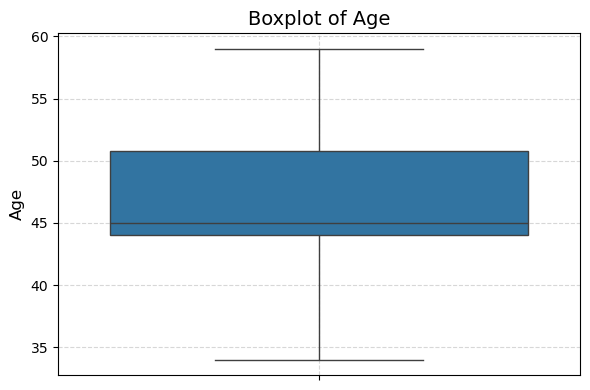

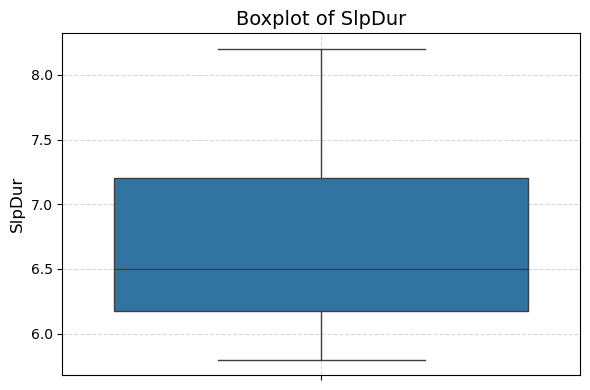

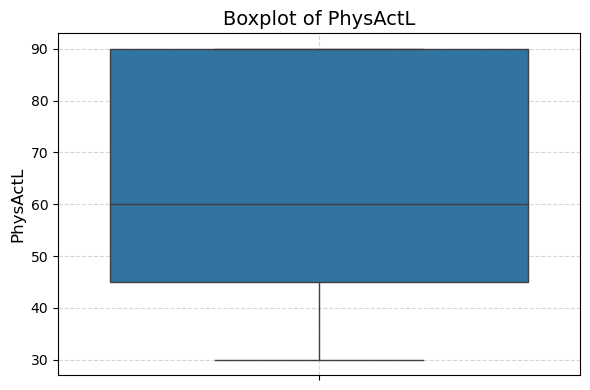

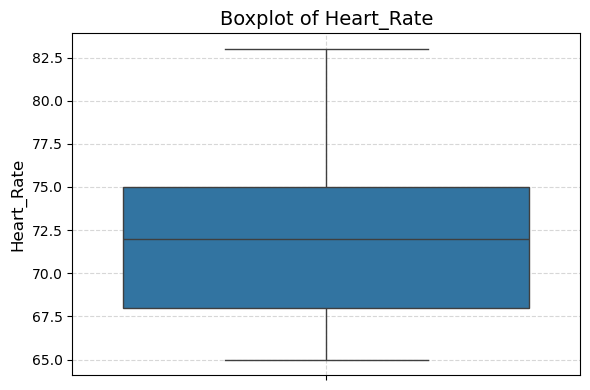

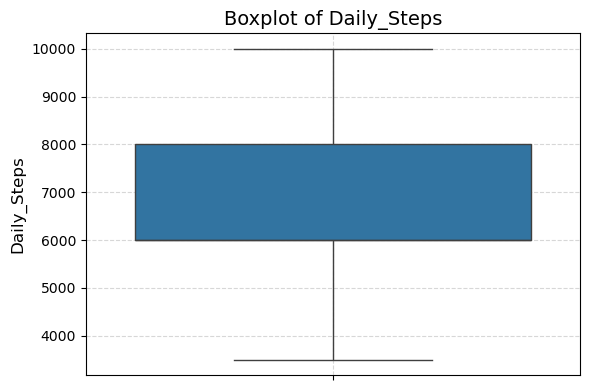

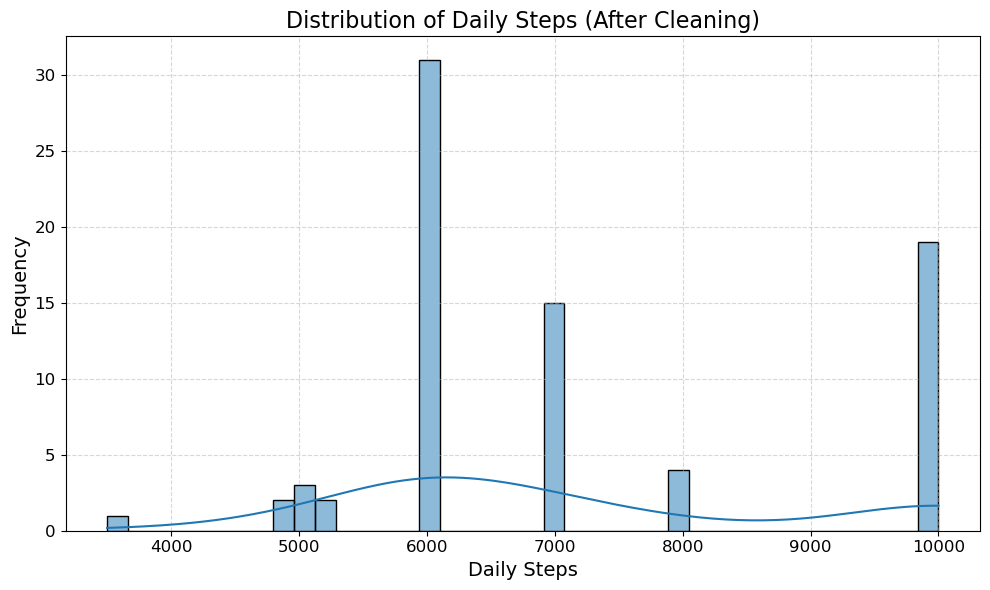

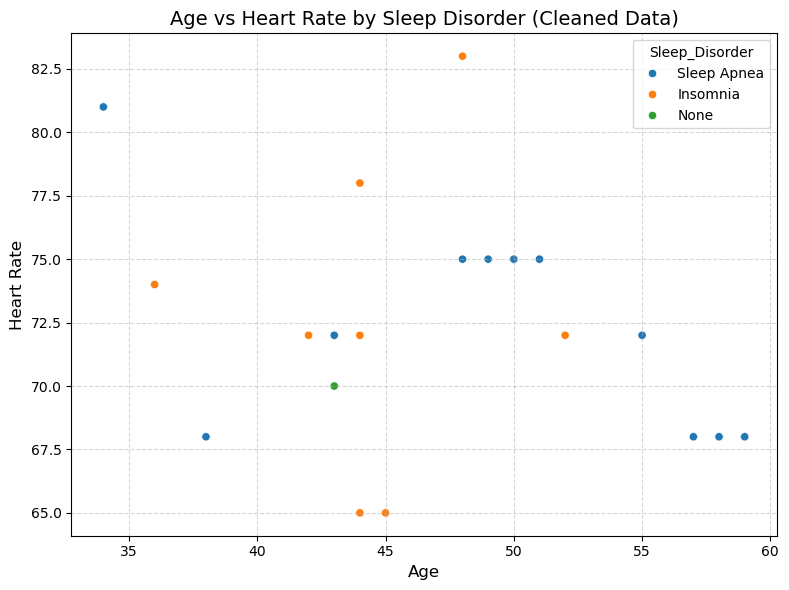

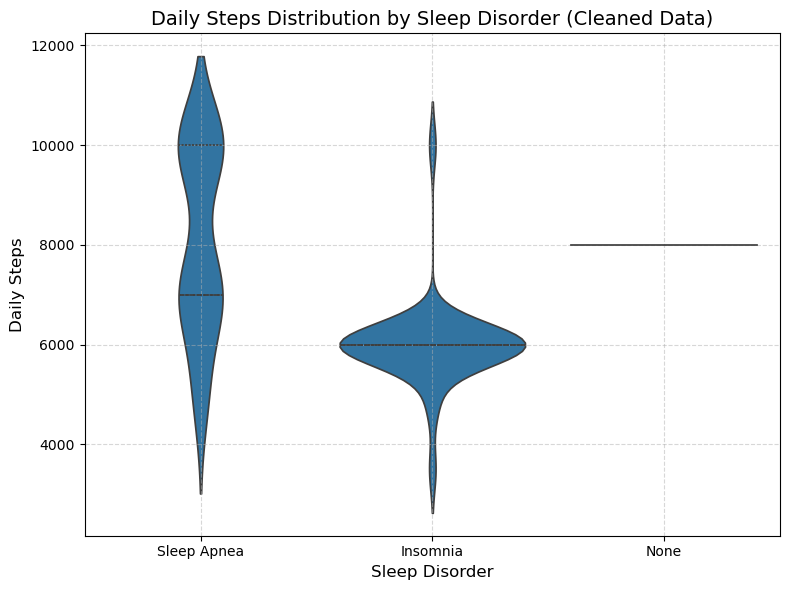

In [150]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = clean_df.select_dtypes(include=[np.number]).columns
numeric_cols = [col for col in numeric_cols if col.lower() != 'id']

#boxplot
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=clean_df[col])
    plt.title(f"Boxplot of {col}", fontsize=14)
    plt.ylabel(col, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

#Histogram for daily ateps
plt.figure(figsize=(10, 6))
sns.histplot(clean_df['Daily_Steps'], bins=40, kde=True)
plt.title("Distribution of Daily Steps (After Cleaning)", fontsize=16)
plt.xlabel("Daily Steps", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 3) Scatter plot Age vs Heart_Rate 
plt.figure(figsize=(8, 6))
sns.scatterplot(x="Age", y="Heart_Rate", hue="Sleep_Disorder", data=clean_df)
plt.title("Age vs Heart Rate by Sleep Disorder (Cleaned Data)", fontsize=14)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Heart Rate", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 4) Violin plot Sleep_Disorder vs Daily_Steps 
plt.figure(figsize=(8, 6))
sns.violinplot(x="Sleep_Disorder", y="Daily_Steps", data=clean_df, inner="quartile")
plt.title("Daily Steps Distribution by Sleep Disorder (Cleaned Data)", fontsize=14)
plt.xlabel("Sleep Disorder", fontsize=12)
plt.ylabel("Daily Steps", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()





Explanation:

**Data Cleaning**
- Identified and corrected inconsistencies:
- Standardized categorical values
- Fixed typos in occupations and BMI categories.
- Converted mixed‑type numeric columns (Age, Heart Rate, Daily Steps) into proper numeric values.
- Removed or replaced impossible values like negative numbers of steps
- Saved the cleaned dataset as consistent_dataset.xlsx

**Outlier Detection**
- Applied the Interquartile Range (IQR) method to numeric columns.
- Detected extreme outliers, especially in Daily Steps (values close to 1,000,000) and some unrealistic heart rate entries.

**Visualization**

- diffrent types of graphs were used
- Boxplots are useful for quick outlier detection\.
- Violin plots and histograms were more suitable for this dataset because they revealed the distribution shape and allowed meaningful comparisons across sleep disorder categories.
- Scatter plots added value by showing relationships between lifestyle factors and health indicators.



##5. Data transformation Encoding



In [153]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

df_encoded = clean_df.copy()

encoder_gender = LabelEncoder()
encoder_sleep = LabelEncoder()
encoder_bmi = LabelEncoder()

# 1) Gender
mask_gender = df_encoded['Gender'].notna()
df_encoded.loc[mask_gender, 'Gender_le'] = encoder_gender.fit_transform(
    df_encoded.loc[mask_gender, 'Gender']
)

# 2) Sleep_Disorder
mask_sleep = df_encoded['Sleep_Disorder'].notna()
df_encoded.loc[mask_sleep, 'Sleep_Disorder_le'] = encoder_sleep.fit_transform(
    df_encoded.loc[mask_sleep, 'Sleep_Disorder']
)

# 3) BMIcategory
mask_bmi = df_encoded['BMIcategory'].notna()
df_encoded.loc[mask_bmi, 'BMIcategory_le'] = encoder_bmi.fit_transform(
    df_encoded.loc[mask_bmi, 'BMIcategory']
)

df_encoded.head()





,id,Gender,Age,Occupation,SlpDur,SlpQ,PhysActL,StressL,BMIcategory,Blood_Pressure,Heart_Rate,Daily_Steps,Sleep_Disorder,Gender_le,Sleep_Disorder_le,BMIcategory_le
6,81,Female,34.0,Scientist,5.8,4,32,8,Overweight,131/86,81.0,5200.0,Sleep Apnea,0.0,2.0,2.0
7,82,Female,34.0,Scientist,5.8,4,32,8,Overweight,NaN,81.0,5200.0,Sleep Apnea,0.0,2.0,2.0
9,104,Male,36.0,Teacher,6.6,5,35,7,Overweight,129/84,74.0,4800.0,Sleep Apnea,1.0,2.0,2.0
10,106,Male,36.0,Teacher,6.6,5,35,Extreme,Overweight,129/84,74.0,4800.0,Insomnia,1.0,0.0,2.0
11,145,Male,38.0,Lawyer,7.1,8,60,5,Normal,130/85,68.0,8000.0,Sleep Apnea,1.0,2.0,0.0


In [154]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

df_scaled = df_encoded.copy()

numeric_cols = [
    'Age', 'SlpDur', 'PhysActL',
    'Heart_Rate', 'Daily_Steps'
]

minmax_scaler = MinMaxScaler()
df_scaled[numeric_cols] = minmax_scaler.fit_transform(df_scaled[numeric_cols])

df_scaled.head()


,id,Gender,Age,Occupation,SlpDur,SlpQ,PhysActL,StressL,BMIcategory,Blood_Pressure,Heart_Rate,Daily_Steps,Sleep_Disorder,Gender_le,Sleep_Disorder_le,BMIcategory_le
6,81,Female,0.00,Scientist,0.000000,4,0.033333,8,Overweight,131/86,0.888889,0.261538,Sleep Apnea,0.0,2.0,2.0
7,82,Female,0.00,Scientist,0.000000,4,0.033333,8,Overweight,NaN,0.888889,0.261538,Sleep Apnea,0.0,2.0,2.0
9,104,Male,0.08,Teacher,0.333333,5,0.083333,7,Overweight,129/84,0.500000,0.200000,Sleep Apnea,1.0,2.0,2.0
10,106,Male,0.08,Teacher,0.333333,5,0.083333,Extreme,Overweight,129/84,0.500000,0.200000,Insomnia,1.0,0.0,2.0
11,145,Male,0.16,Lawyer,0.541667,8,0.500000,5,Normal,130/85,0.166667,0.692308,Sleep Apnea,1.0,2.0,0.0


In [205]:
# Save the final cleaned + encoded + scaled dataset
df_scaled.to_excel("final_clean_scaled_dataset.xlsx", index=False)

print("File saved successfully as final_clean_scaled_dataset.xlsx")


File saved successfully as final_clean_scaled_dataset.xlsx


## 6. Summary of data preparation



During the data preparation phase, our dataset went through several essential steps to ensure it was clean, consistent, and ready for further analysis. We first explored all variables and identified their types, especially focusing on columns such as Gender, Age, Occupation, SlpDur, SlpQ, PhysActL, StressL, BMIcategory, Blood_Pressure, Heart_Rate, Daily_Steps, and Sleep_Disorder. At this stage, we also detected inconsistencies like mixed letter cases, unexpected string values, and duplicated rows.

Next, the missing values were handled by either dropping incomplete rows or replacing them using the mean or median, depending on the behavior of each numerical column. After that, issues such as negative or illogical values were fixed, and outliers were detected using the IQR method, especially in numerical fields like Age, SlpDur, PhysActL, Heart_Rate, and Daily_Steps. Some visualizations (such as boxplots) were also generated to better understand the spread of these features.

Once the data was cleaned, categorical variables were encoded. Columns like Gender and Sleep_Disorder were transformed using Label Encoding, while multi-category columns such as Occupation, BMIcategory, and Blood_Pressure were processed using One-Hot Encoding. Finally, numerical features—specifically Age, SlpDur, PhysActL, Heart_Rate, and Daily_Steps—underwent scaling using both StandardScaler and MinMaxScaler to normalize their ranges.

Overall, these preparation steps ensured that our dataset became structured, reliable, and fully ready for any modeling or analysis that follows.

# Model Planning

## Statistical summary


,count,mean,std,min,25%,50%,75%,max,median,IQR
Age,78.0,0.550256,0.260125,0.0,0.400000,0.440000,0.670000,1.0,0.440000,0.270000
SlpDur,80.0,0.402604,0.318288,0.0,0.156250,0.291667,0.583333,1.0,0.291667,0.427083
PhysActL,80.0,0.544583,0.345737,0.0,0.250000,0.500000,1.000000,1.0,0.500000,0.750000
Heart_Rate,68.0,0.321895,0.241982,0.0,0.166667,0.388889,0.555556,1.0,0.388889,0.388889
Daily_Steps,77.0,0.563437,0.275876,0.0,0.384615,0.384615,0.692308,1.0,0.384615,0.307692


--- Gender ---


Gender
Female    54
Male      26
Name: count, dtype: int64

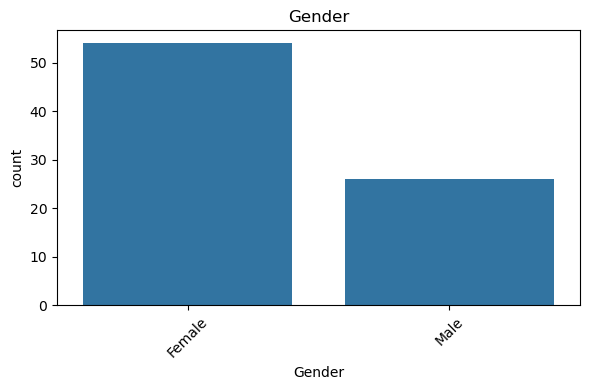

--- Occupation ---


Occupation
Nurse          35
Teacher        18
Salesperson    17
Lawyer          3
Engineer        3
Scientist       2
Doctor          1
Accountant      1
Name: count, dtype: int64

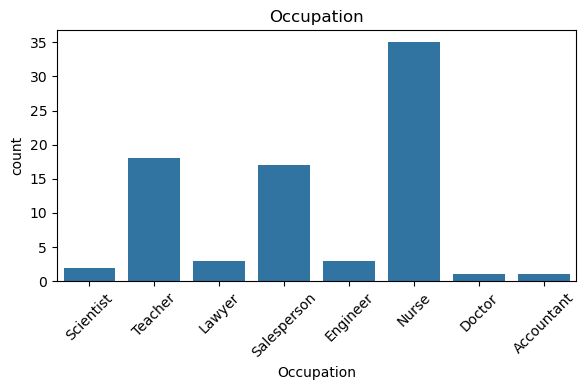

--- BMIcategory ---


BMIcategory
Overweight    71
Normal         6
Unknown        2
Obese          1
Name: count, dtype: int64

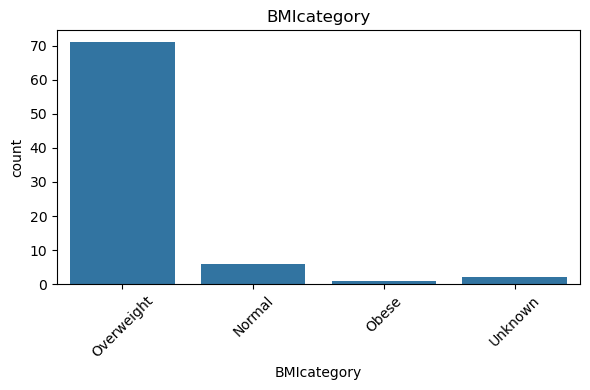

--- Blood_Pressure ---


Blood_Pressure
140/95    35
130/85    24
135/90    15
NaN        2
129/84     2
131/86     1
142/92     1
Name: count, dtype: int64

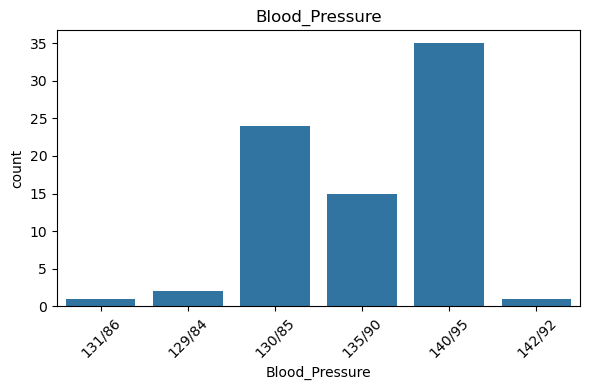

--- Sleep_Disorder ---


Sleep_Disorder
Sleep Apnea    39
Insomnia       36
NaN             4
None            1
Name: count, dtype: int64

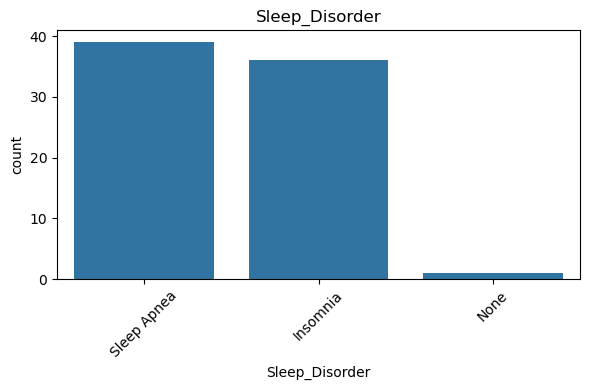

In [160]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#numerical columns
numeric_cols = ['Age','SlpDur','PhysActL','Heart_Rate','Daily_Steps']

#categorical columns
categorical_cols = ['Gender','Occupation','BMIcategory','Blood_Pressure','Sleep_Disorder']

#numerical summary
numeric_summary = df_scaled[numeric_cols].describe().T
numeric_summary['median'] = df_scaled[numeric_cols].median()
numeric_summary['IQR'] = numeric_summary['75%'] - numeric_summary['25%']

display(numeric_summary)

#categorical summary
for col in categorical_cols:
    print(f"--- {col} ---")
    display(clean_df[col].value_counts(dropna=False))

    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=clean_df)
    plt.title(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



## Data Visualization and Insights


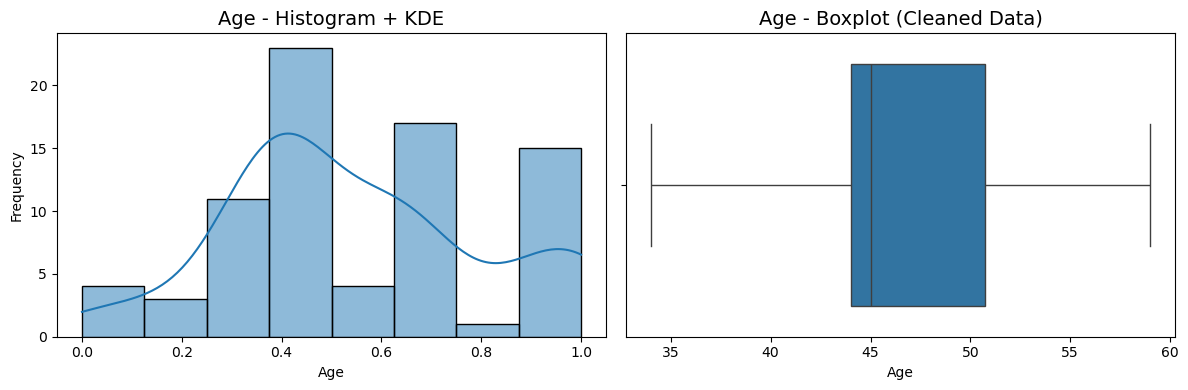

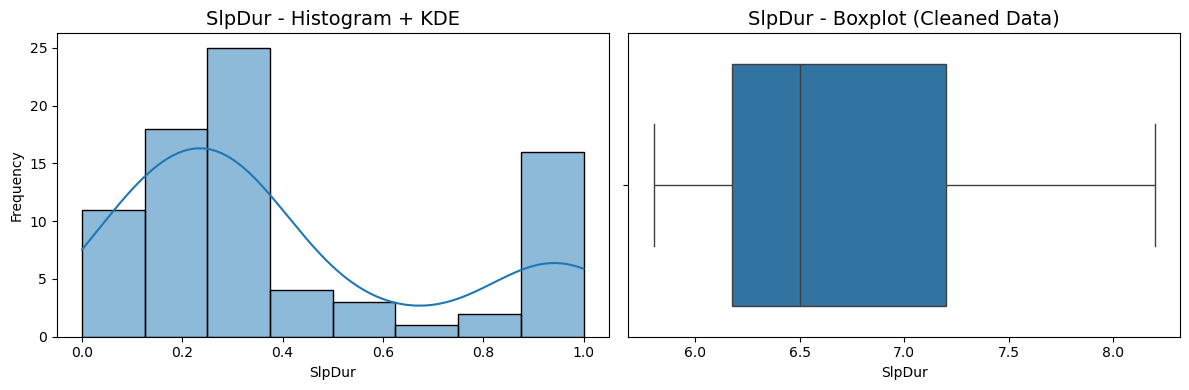

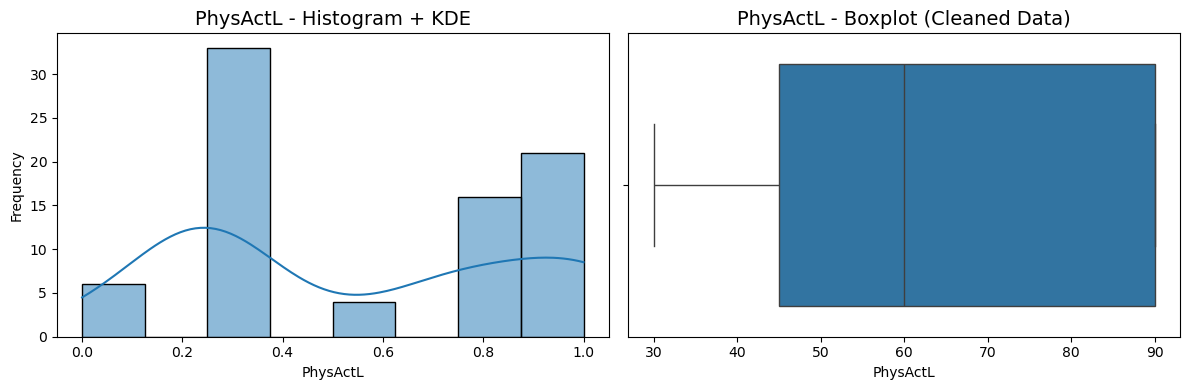

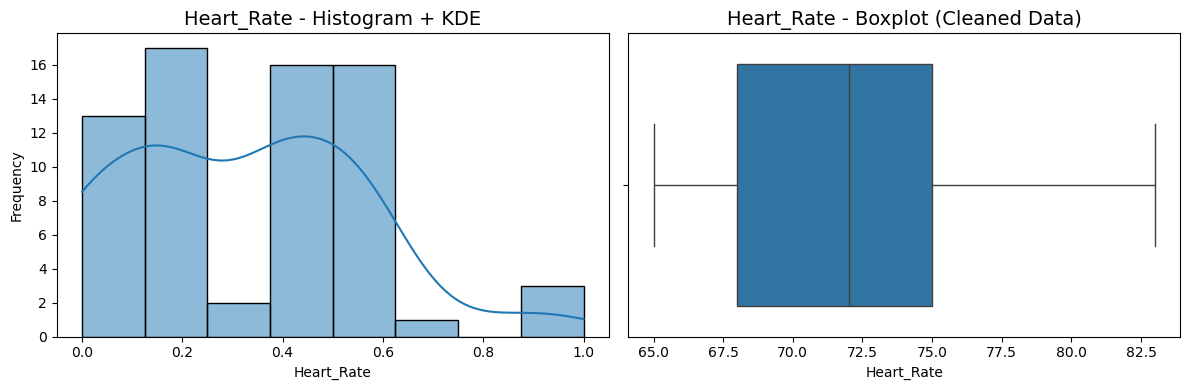

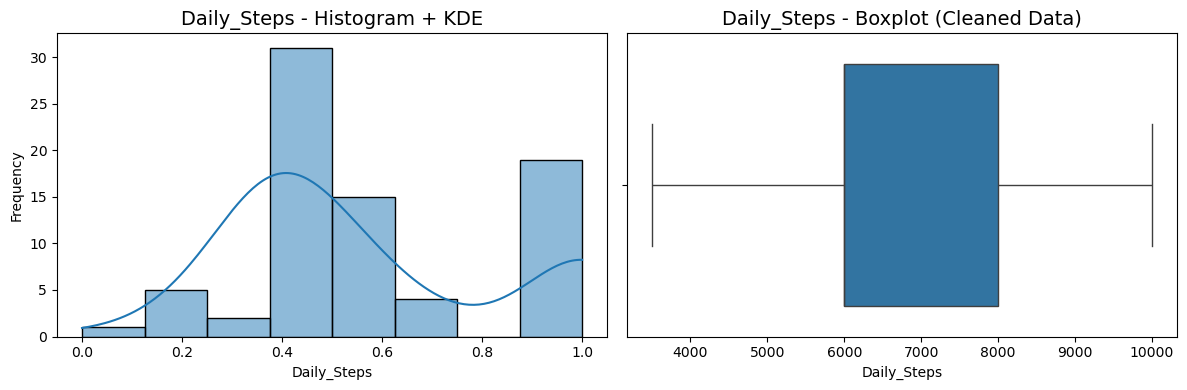

In [162]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = ['Age','SlpDur','PhysActL','Heart_Rate','Daily_Steps']

# df_scaled → Histogram
# clean_df  → Boxplot 
df_hist = df_scaled.copy()
df_box = clean_df.copy()

for col in numeric_cols:
    plt.figure(figsize=(12, 4))

#Hidtogram + KDE
    plt.subplot(1, 2, 1)
    sns.histplot(df_hist[col].dropna(), kde=True)
    plt.title(f"{col} - Histogram + KDE", fontsize=14)
    plt.xlabel(col)
    plt.ylabel("Frequency")

    # Boxplot (before scaling)
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_box[col].dropna())
    plt.title(f"{col} - Boxplot (Cleaned Data)", fontsize=14)
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()


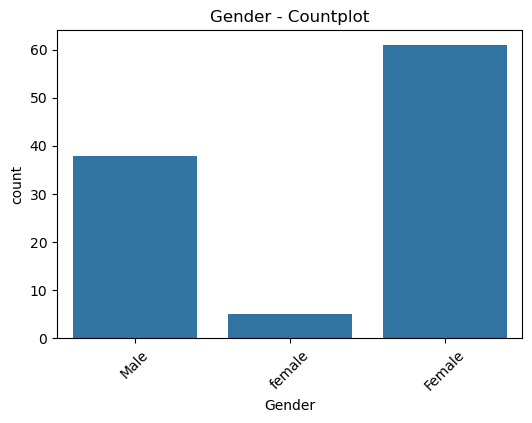

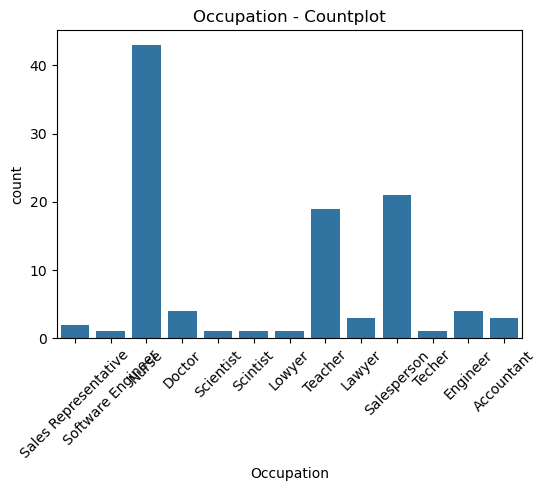

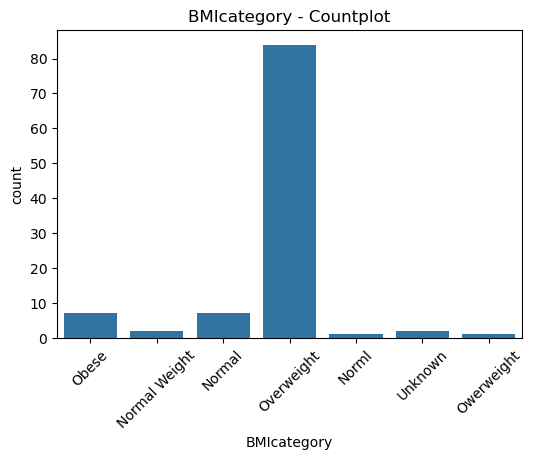

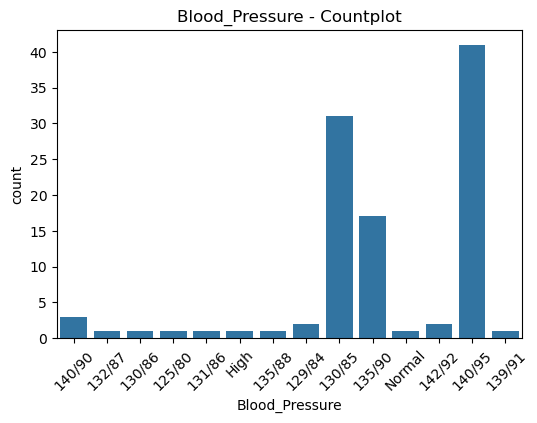

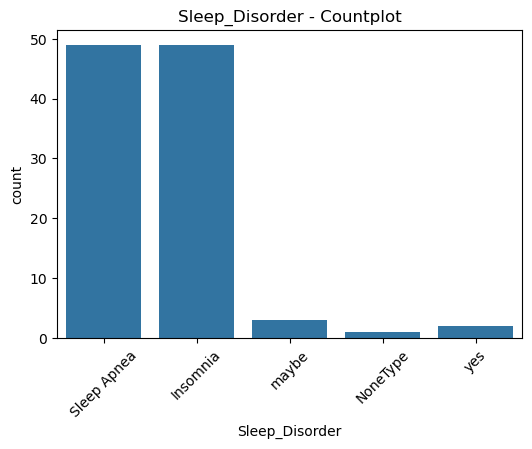

In [163]:
categorical_cols = ['Gender','Occupation','BMIcategory','Blood_Pressure','Sleep_Disorder']

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.title(f"{col} - Countplot")
    plt.xticks(rotation=45)
    plt.show()

 # Analysis


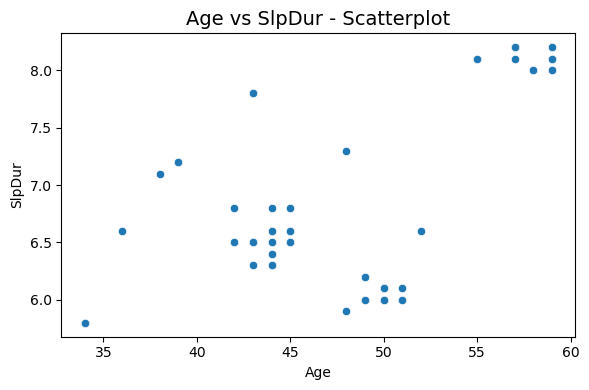

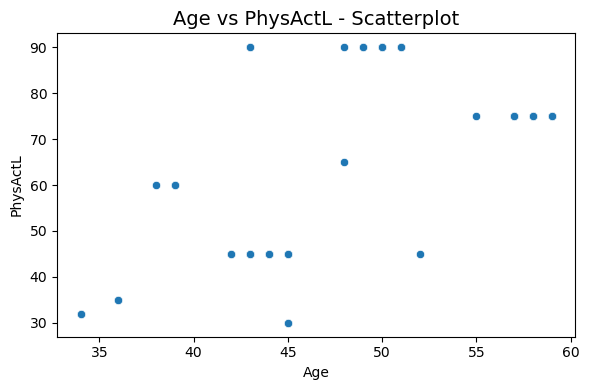

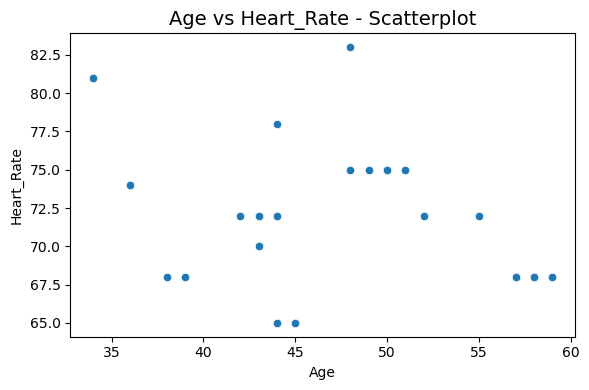

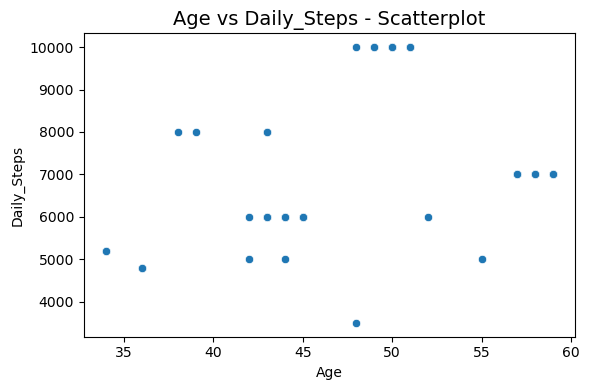

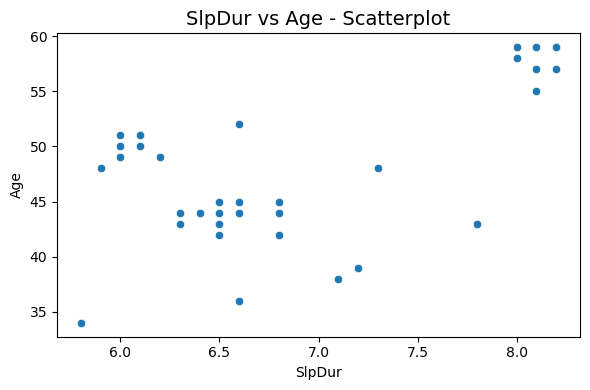

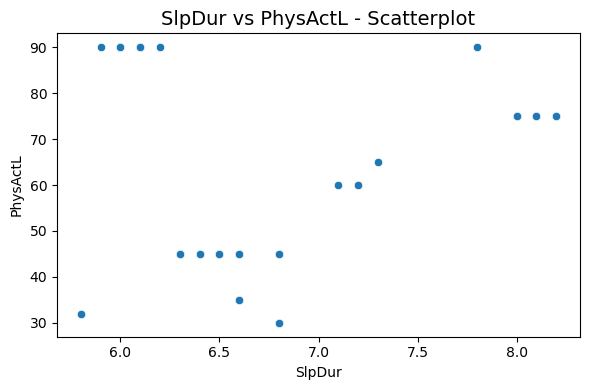

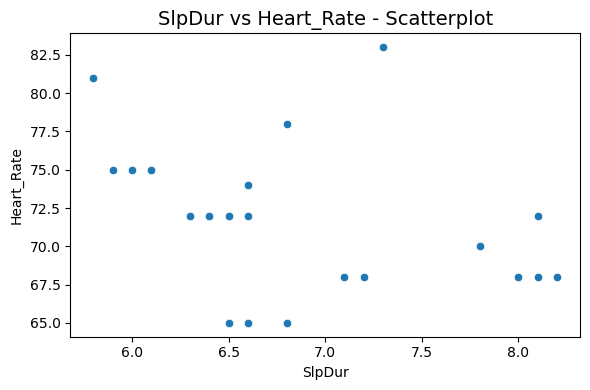

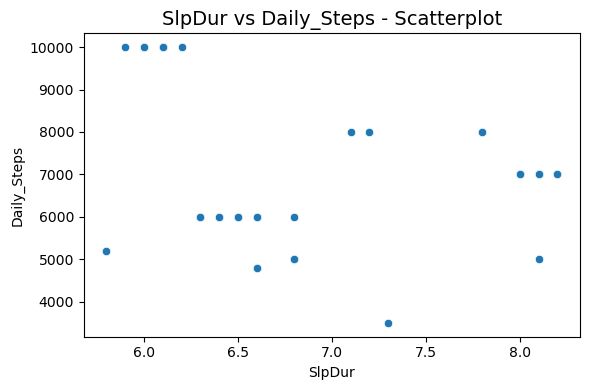

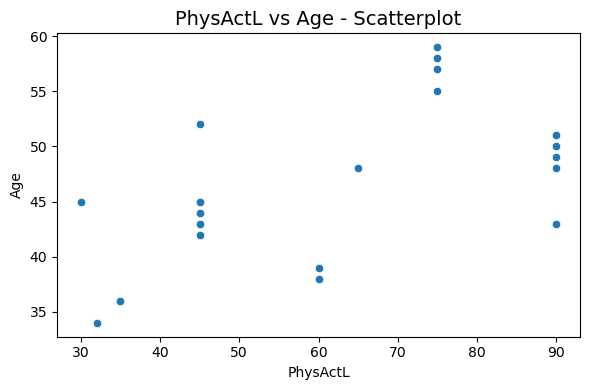

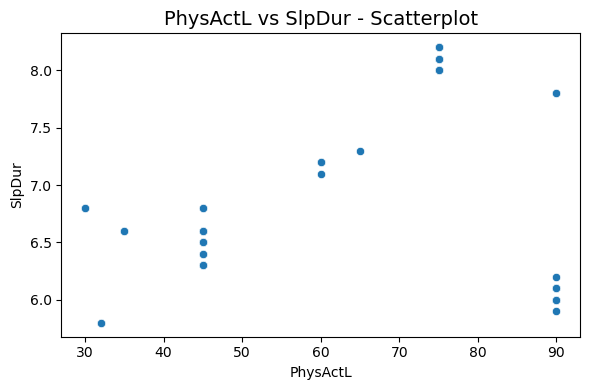

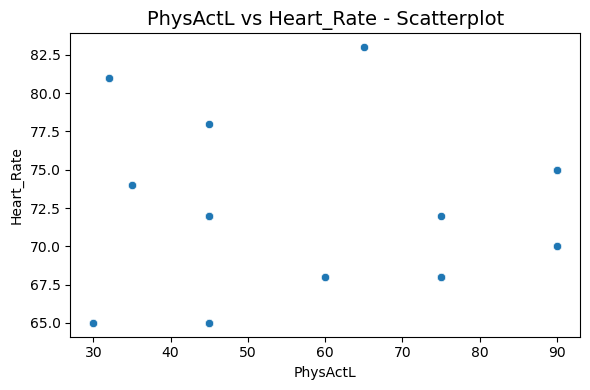

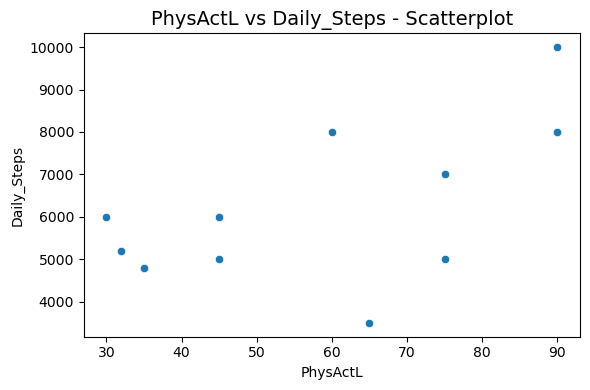

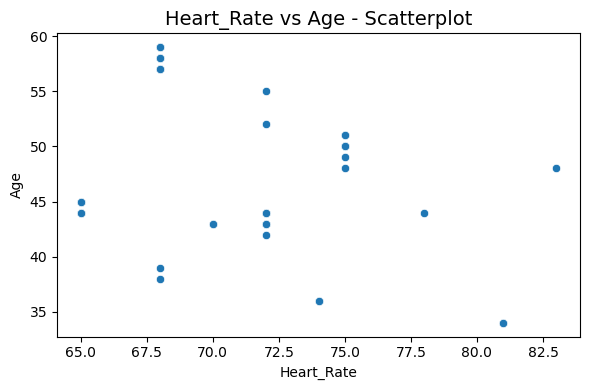

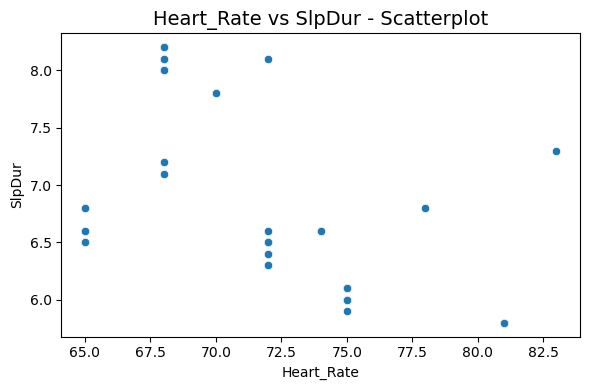

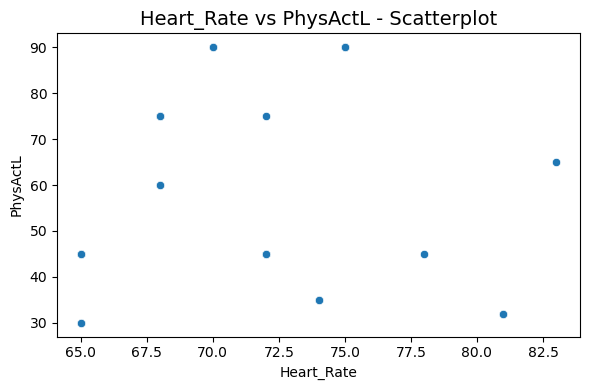

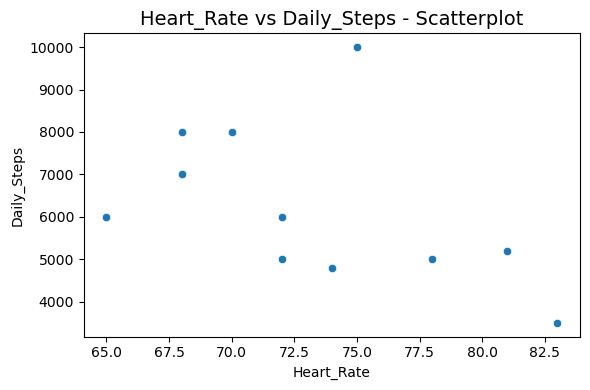

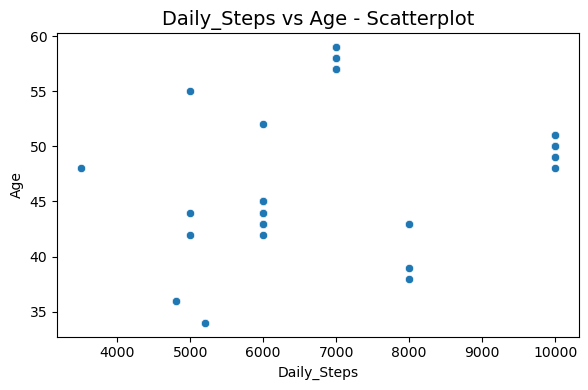

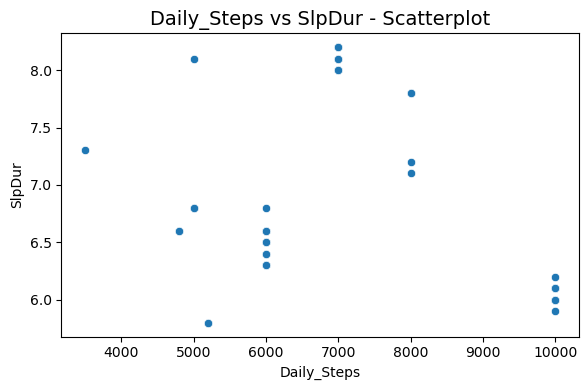

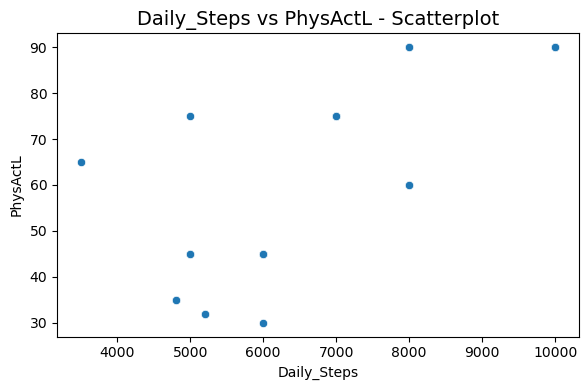

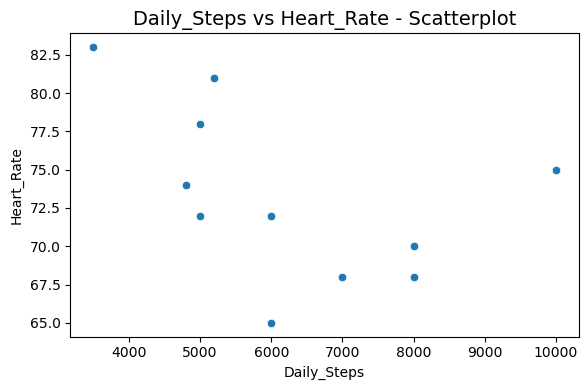

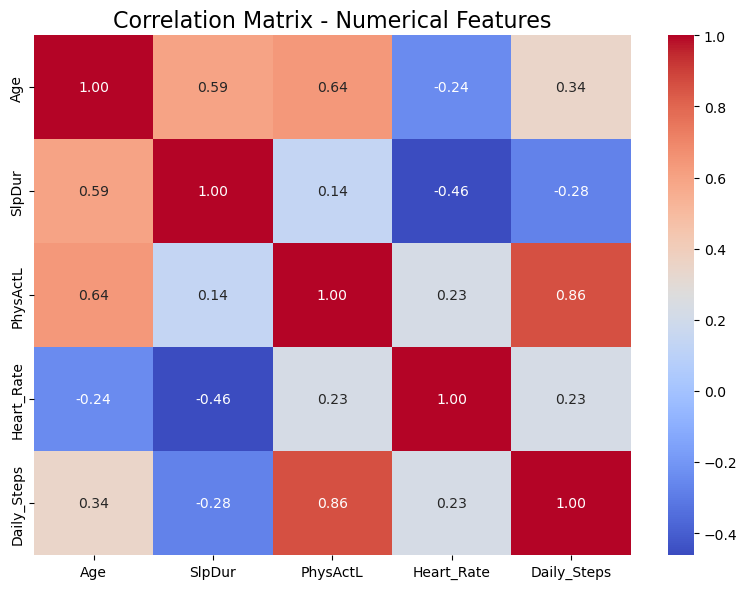

In [165]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = ['Age','SlpDur','PhysActL','Heart_Rate','Daily_Steps']

df_scatter = clean_df.copy()  
df_corr = df_scaled.copy()    

# Numerical vs Numerical Scatterplots
for col1 in numeric_cols:
    for col2 in numeric_cols:
        if col1 != col2:
            plt.figure(figsize=(6,4))
            sns.scatterplot(x=df_scatter[col1].dropna(), y=df_scatter[col2].dropna())
            plt.title(f"{col1} vs {col2} - Scatterplot", fontsize=14)
            plt.xlabel(col1)
            plt.ylabel(col2)
            plt.tight_layout()
            plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df_corr[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix - Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()


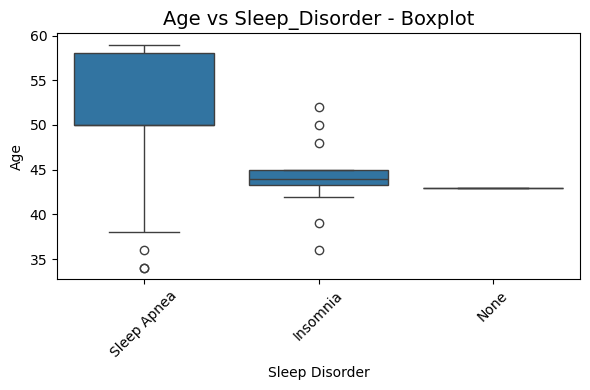

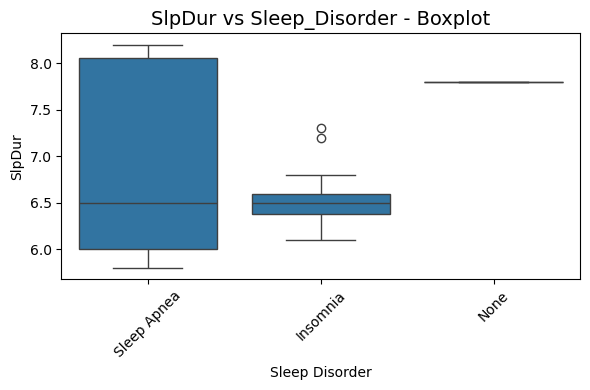

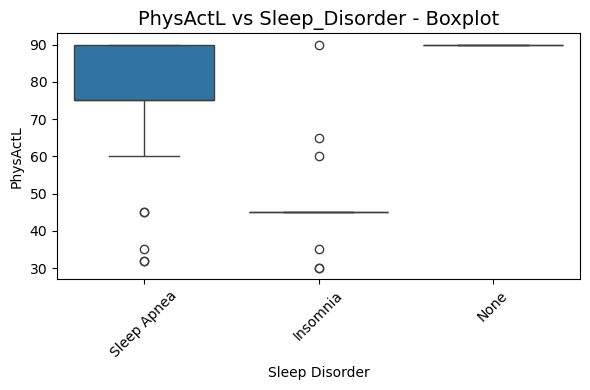

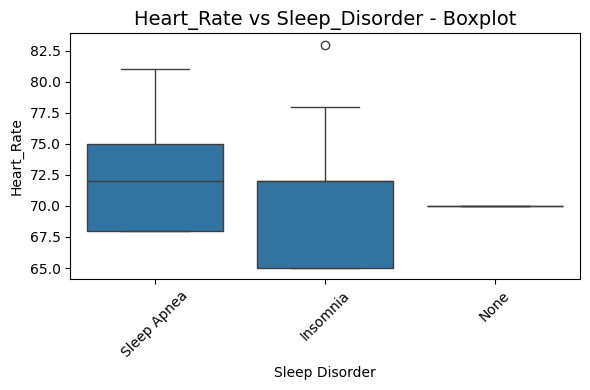

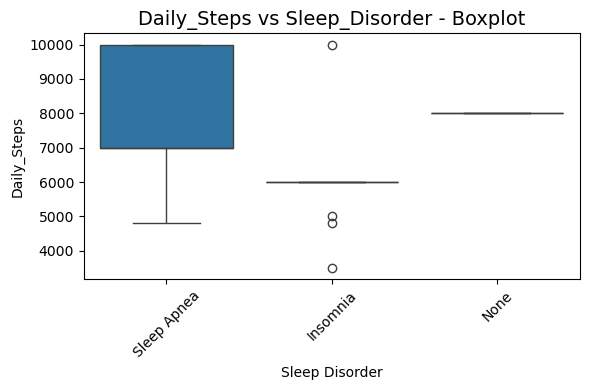

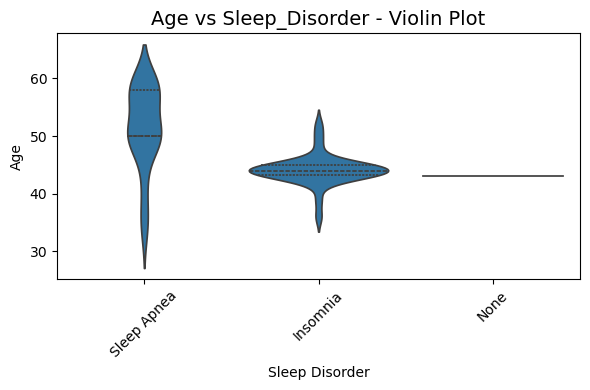

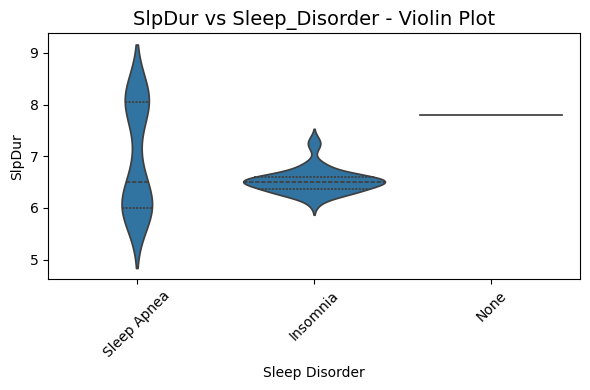

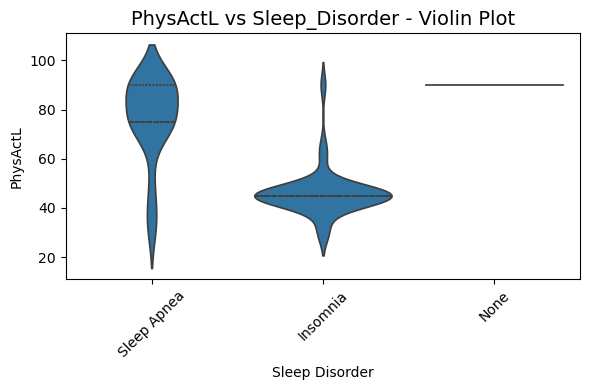

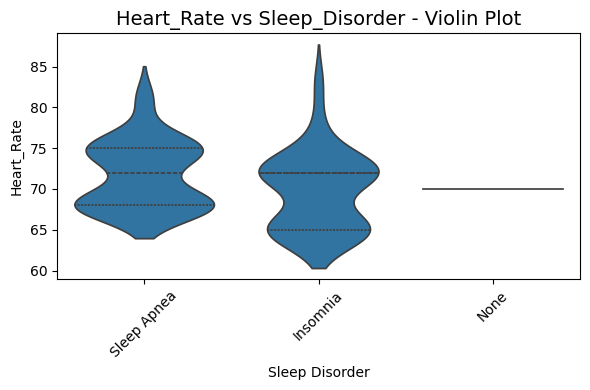

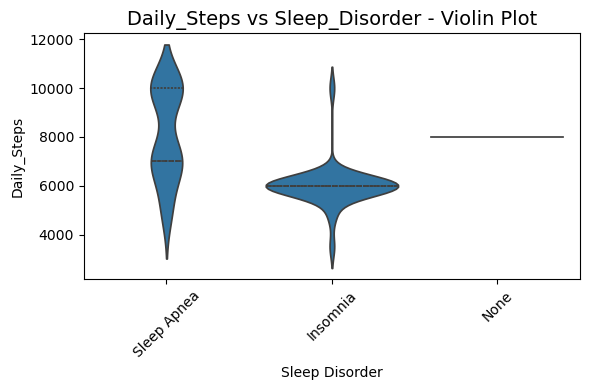

,Age,SlpDur,PhysActL,Heart_Rate,Daily_Steps
Sleep_Disorder,,,,,
Insomnia,44.147059,6.527778,46.111111,69.774194,5978.787879
None,43.000000,7.800000,90.000000,70.000000,8000.000000
Sleep Apnea,51.384615,6.946154,76.384615,71.757576,8056.410256


In [166]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = ['Age','SlpDur','PhysActL','Heart_Rate','Daily_Steps']

df_plot = clean_df.copy()

df_plot = df_plot.dropna(subset=['Sleep_Disorder'])

# --- Boxplots ---
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_plot['Sleep_Disorder'], y=df_plot[col])
    plt.title(f"{col} vs Sleep_Disorder - Boxplot", fontsize=14)
    plt.xlabel("Sleep Disorder")
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# --- Violin Plots ---
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.violinplot(x=df_plot['Sleep_Disorder'], y=df_plot[col], inner="quartile")
    plt.title(f"{col} vs Sleep_Disorder - Violin Plot", fontsize=14)
    plt.xlabel("Sleep Disorder")
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# --- Groupby Mean ---
df_plot.groupby('Sleep_Disorder')[numeric_cols].mean()


---- Crosstab: Gender vs Sleep_Disorder ----


Sleep_Disorder,Insomnia,None,Sleep Apnea
Gender,,,
Female,16,0,36
Male,20,1,3


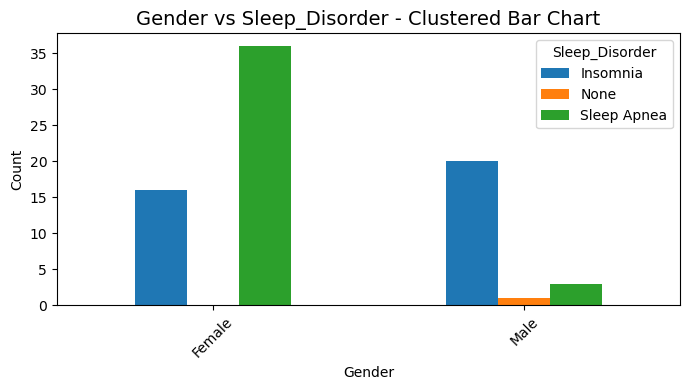

---- Crosstab: Occupation vs Sleep_Disorder ----


Sleep_Disorder,Insomnia,None,Sleep Apnea
Occupation,,,
Accountant,1,0,0
Doctor,1,0,0
Engineer,1,1,0
Lawyer,1,0,1
Nurse,1,0,33
Salesperson,16,0,1
Scientist,0,0,2
Teacher,15,0,2


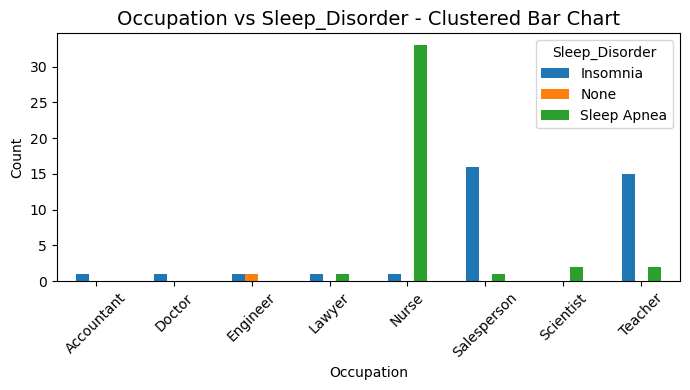

---- Crosstab: BMIcategory vs Sleep_Disorder ----


Sleep_Disorder,Insomnia,None,Sleep Apnea
BMIcategory,,,
Normal,2,1,1
Obese,1,0,0
Overweight,33,0,36
Unknown,0,0,2


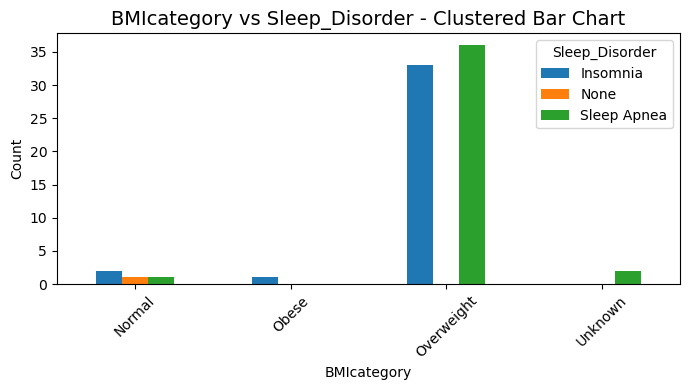

---- Crosstab: Blood_Pressure vs Sleep_Disorder ----


Sleep_Disorder,Insomnia,None,Sleep Apnea
Blood_Pressure,,,
129/84,1,0,1
130/85,18,1,3
131/86,0,0,1
135/90,14,0,0
140/95,1,0,33
142/92,1,0,0
NaN,1,0,1


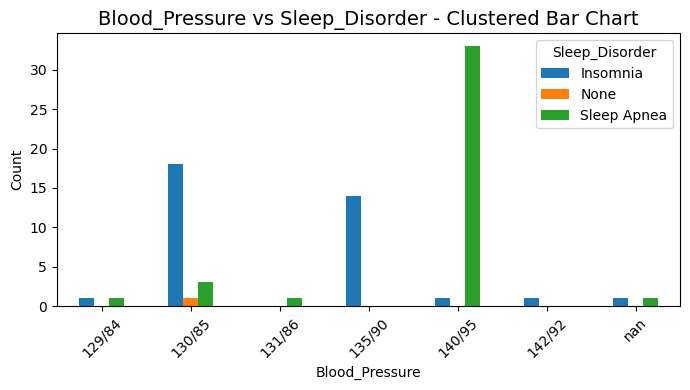

In [167]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

categorical_cols = ['Gender', 'Occupation', 'BMIcategory', 'Blood_Pressure']
target = 'Sleep_Disorder'

df_cat = clean_df.copy()

df_cat = df_cat.dropna(subset=[target])

for col in categorical_cols:
    print(f"---- Crosstab: {col} vs {target} ----")
    
    #crosstab
    ct = pd.crosstab(df_cat[col], df_cat[target], dropna=False)
    display(ct)

    # clustered bar chart 
    ct.plot(kind='bar', figsize=(7,4))
    plt.title(f"{col} vs {target} - Clustered Bar Chart", fontsize=14)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


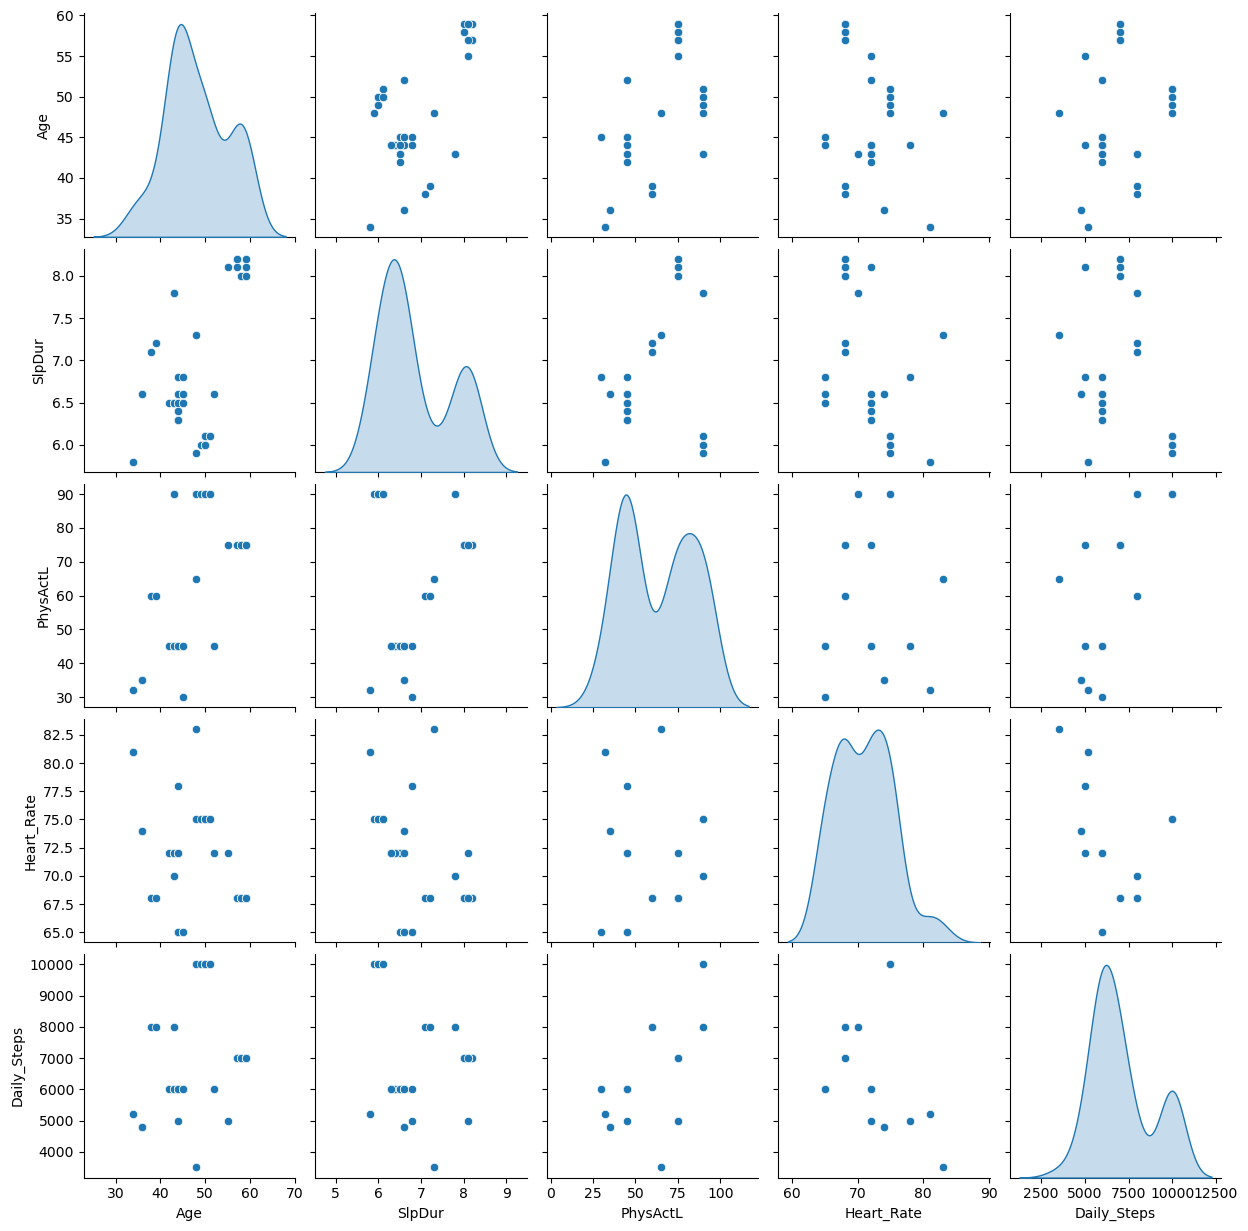

In [168]:
import seaborn as sns
import matplotlib.pyplot as plt

#pairplot

numeric_cols = ['Age','SlpDur','PhysActL','Heart_Rate','Daily_Steps']

df_eda = clean_df[numeric_cols].dropna()   # Pairplot ما يتحمل NaN

sns.pairplot(df_eda, diag_kind='kde')
plt.show()



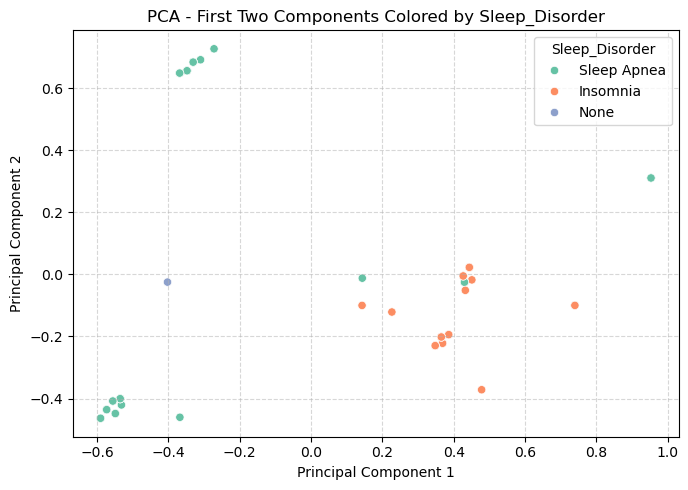

In [169]:
#PCA

from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

numeric_cols = ['Age','SlpDur','PhysActL','Heart_Rate','Daily_Steps']

X = df_scaled[numeric_cols]

mask_no_nan = X.notna().all(axis=1)

X_clean = X[mask_no_nan]

# PCA 
pca = PCA(n_components=2)
components = pca.fit_transform(X_clean)

pca_df = pd.DataFrame(components, columns=['PC1', 'PC2'])

pca_df['Sleep_Disorder'] = clean_df.loc[mask_no_nan, 'Sleep_Disorder'].values

pca_df = pca_df.dropna(subset=['Sleep_Disorder'])

#plot
plt.figure(figsize=(7,5))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Sleep_Disorder', palette='Set2')
plt.title("PCA - First Two Components Colored by Sleep_Disorder")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



# **7. Summary of Exploratory Data Analysis**

During the exploratory data analysis (EDA) phase, we examined the dataset from multiple perspectives to better understand the structure, distributions, and relationships between the variables. This step was essential before moving into model planning and building. The EDA included statistical summaries, univariate and bivariate visualizations, multivariate (advanced) plots, and an assessment of variable relationships.

### **1. Statistical Summaries**
We began by generating descriptive statistics for all numerical features, including Age, Sleep Duration (SlpDur), Physical Activity Level (PhysActL), Heart Rate, and Daily Steps. These summaries helped identify central tendencies, variability, and potential irregularities in the data.  
For categorical features such as Gender, Occupation, BMIcategory, Blood_Pressure, and Sleep_Disorder, frequency tables were created to understand distribution and class balance across categories.

### **2. Univariate Analysis**
To explore the behavior of each variable individually, histograms with KDE curves were plotted for all numerical columns. These visualizations revealed the overall distribution shape, skewness, and spread.  
Additionally, boxplots were used to identify extreme values and visualize the range of each numerical variable. For categorical variables, countplots were generated to show the distribution of each class.

### **3. Bivariate Analysis**
Several bivariate relationships were explored to assess dependencies between variables:

- **Numerical vs Numerical:** Scatterplots and a correlation heatmap revealed weak to moderate correlations. Certain features, such as Sleep Duration and Physical Activity, showed notable interaction patterns.

- **Numerical vs Categorical:** Boxplots and violin plots highlighted clear differences across Sleep Disorder categories. For example, Sleep Apnea cases showed higher heart rates and higher daily steps, while Insomnia cases generally had lower physical activity and shorter sleep duration.

- **Categorical vs Categorical:** Crosstabs and clustered bar charts revealed differences in sleep disorder distributions across gender, BMI categories, and occupation groups.

### **4. Advanced Visualizations**
To inspect multivariate patterns, two advanced techniques were applied:

- **Pairplot:** This provided a complete visual overview of relationships among all numerical variables.

- **PCA (Principal Component Analysis):** By reducing dimensionality into two principal components, PCA exposed partial clustering between Sleep Disorder categories. Sleep Apnea and Insomnia formed distinguishable patterns, while the “None” class was more dispersed.

### **5. Relationship Assessment**
Overall, the EDA findings indicate that Sleep Disorder categories are influenced by multiple variables, especially Physical Activity Level, Sleep Duration, Daily Steps, and Heart Rate.  
These observable patterns justify the application of classification models to predict sleep disorder type in the next phase.





## Model Planning
We selected the classification approach because our target variable (Sleep Disorder) is categorical, not numerical. The goal of the model is to predict the user’s sleep-health condition based on lifestyle and health measurements. Since the output consists of distinct categories, classification is the most suitable method.

The main objectives of the modeling phase are to:
Predict whether the user has a sleep disorder based on their health and lifestyle patterns.
Understand which features contribute most to the classification outcome.
Build a model that is accurate, reliable, and able to generalize well to new data.

Why Random Forest Classifier?
We chose to use the Random Forest Classifier because it is a powerful ensemble method that combines multiple decision trees to improve prediction accuracy and reduce overfitting. Random Forest handles both numerical and categorical variables effectively, works well with complex datasets, and provides feature importance metrics that help us understand which variables contribute the most to the prediction.

Selected Features
The features selected for modeling include:
Age
Sleep Duration
Physical Activity Level
Heart Rate
Daily Steps
Gender
Occupation
BMI Category
Blood Pressure

These features were selected because they strongly influence sleep quality and overall health, making them useful predictors for identifying sleep disorders.

Target Variable
The target variable for the model is: Sleep Disorder.

## Model building

In [207]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1) Load the CLEAN dataset (replace the file name with your clean file)
df_clean = pd.read_excel("Sleep_health_and_lifestyle_dataset_clean.xlsx")

# 2) Encode categorical columns
cat_cols = ["Gender", "Occupation", "BMIcategory", "Blood_Pressure", "Sleep_Disorder"]

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_clean[col + "_le"] = le.fit_transform(df_clean[col].astype(str))
    encoders[col] = le

# 3) Define features (X) and target (y)
feature_cols = [
    "Age",
    "SlpDur",
    "PhysActL",
    "Heart_Rate",
    "Daily_Steps",
    "Gender_le",
    "Occupation_le",
    "BMIcategory_le",
    "Blood_Pressure_le"
]

X = df_clean[feature_cols]
y = df_clean["Sleep_Disorder_le"]

# 4) Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 5) Create and train the Decision Tree model
dt_clf = DecisionTreeClassifier(
    criterion="gini",
    max_depth=None,
    random_state=42
)

dt_clf.fit(X_train, y_train)

# 6) Evaluation
y_pred = dt_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

FileNotFoundError: [Errno 2] No such file or directory: 'Sleep_health_and_lifestyle_dataset_clean.xlsx'